# Phase 2: Exploring the TESS Input Catalog (TIC)

In this notebook, we explore the structured stellar data provided by the TIC. 
While the light curve (time-series) tells us that a "dip" occurred, the TIC tells us *what kind of star* we are looking at.

## Why is this important?
If a 1% dip happens on a tiny Red Dwarf, it might be a Jupiter-sized planet.
If a 1% dip happens on a massive Blue Giant, it's almost certainly an Eclipsing Binary star, because a planet would be too small to block 1% of a giant star's light.

This is why our SOTA Multimodal Model feeds TIC data into an MLP branch!

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tic_fetcher import fetch_tic_parameters, preprocess_tic_features

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Fetching TIC Attributes
Instead of downloading the 10GB CSV files, we query the MAST API on-demand for a mix of known planet hosts and random stars.

In [2]:
# A small sample of diverse TIC IDs for demonstration
# Includes known planet hosts (e.g., WASP-126) and others.
sample_tics = ["25155310", "279741379", "270304953", "100100827", "300015238", "149603524", "261136679"]

tic_df = fetch_tic_parameters(sample_tics)
display(tic_df.head())

Querying MAST API for 7 targets...


,ID,Tmag,Teff,logg,rad,mass,rho,lum,d,ebv,ra,dec,contratio
0,25155310,10.6103,5675.54,4.25432,1.24175,1.01,0.527499,1.441418,216.5260,0.036369,63.373940,-69.226823,0.026074
1,270304953,18.6991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,331.250842,-26.322547,NaN
2,149603524,9.7109,6391.00,4.37665,1.21427,1.28,0.714926,2.216167,175.6310,0.020258,87.139974,-63.988441,0.016392
3,100100827,8.8287,6226.00,4.25879,1.34658,1.20,0.491460,2.454670,123.4830,0.008131,24.354306,-45.677882,0.002438
4,261136679,5.1054,5992.10,4.35890,1.14889,1.10,0.725369,1.533086,18.2702,0.000000,84.291188,-80.469120,0.000375


## 2. Pitfalls & Missing Data
The biggest pitfall with TIC data is **Missing Values**.
Not every star in the sky has a perfectly measured mass, radius, or temperature.

If we just drop rows with NaNs (`df.dropna()`), we will throw away valid light curves!
Therefore, we must **impute** (e.g., fill with the median).

In [3]:
print("Missing values per column:")
print(tic_df.isnull().sum())

# Apply our robust preprocessing (imputation + normalization)
clean_df = preprocess_tic_features(tic_df)
display(clean_df.head())

Missing values per column:
ID           0
Tmag         0
Teff         1
logg         1
rad          1
mass         1
rho          1
lum          1
d            1
ebv          1
ra           0
dec          0
contratio    1
dtype: int64


,ID,Tmag,Teff,logg,rad,mass,rho,lum,d,ebv,ra,dec,contratio
0,25155310,0.278054,-0.408278,-0.183447,-0.120456,-0.524531,-0.369824,-0.434277,1.527022,1.926009,-0.426263,-0.510204,-0.380328
1,270304953,2.019073,0.268211,0.072543,-0.151609,0.160856,-0.217973,-0.257584,-0.170453,-0.418504,2.188259,1.850562,-0.381737
2,149603524,0.084469,0.708191,0.390882,-0.182761,0.797287,-0.066122,-0.118280,1.006083,0.756658,-0.194302,-0.221967,-0.383145
3,100100827,-0.105414,0.450710,-0.162461,0.117224,0.405637,-0.428221,-0.021002,0.341798,-0.123430,-0.807100,0.785553,-0.387206
4,261136679,-0.906811,0.085711,0.307547,-0.330997,-0.083925,-0.049201,-0.396888,-0.998451,-0.713577,-0.222107,-1.128801,-0.387806


## 3. Data Relations & Trend Analysis
Let's visualize the relationship between Temperature (`Teff`), Radius (`rad`), and Surface Gravity (`logg`).

**Astrophysical Trend:** On the Main Sequence, as stars get hotter (`Teff` increases), they generally get larger (`rad` increases) and less dense (`logg` decreases).
Our neural network will learn this physical constraint from the data.

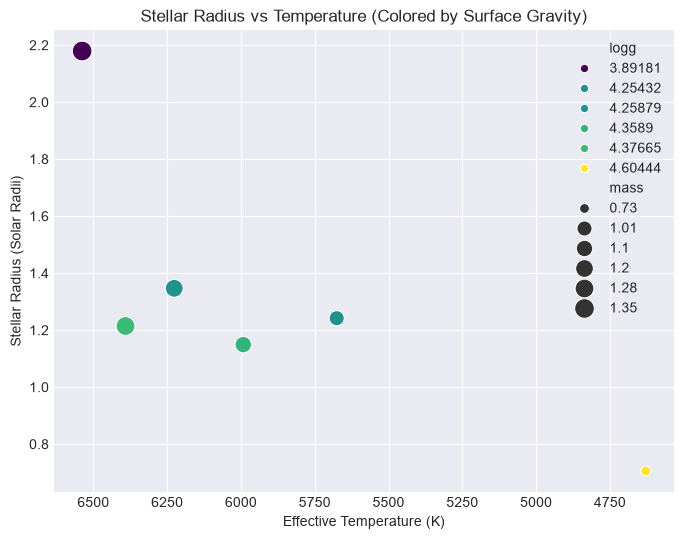

In [4]:
if not tic_df.empty:
    # We plot the raw (unnormalized) data for better physical interpretation
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=tic_df, x='Teff', y='rad', hue='logg', size='mass', sizes=(50, 200), palette='viridis')
    plt.title("Stellar Radius vs Temperature (Colored by Surface Gravity)")
    plt.xlabel("Effective Temperature (K)")
    plt.ylabel("Stellar Radius (Solar Radii)")
    plt.gca().invert_xaxis()  # Astronomy convention: hotter stars on the left
    plt.show()
else:
    print("No data fetched to plot.")

## 4. Feature Correlation
We can use a correlation matrix to see which features are highly correlated.
For instance, `mass` and `rad` are usually highly positively correlated for main-sequence stars.

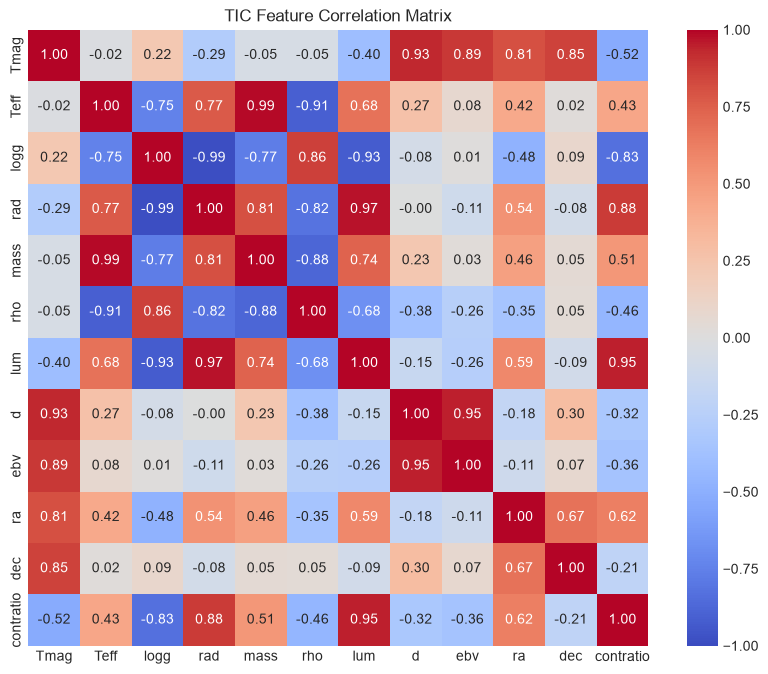

In [5]:
if not tic_df.empty:
    plt.figure(figsize=(10, 8))
    # Calculate correlation matrix on numeric columns only
    corr = tic_df.drop(columns=['ID']).corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title("TIC Feature Correlation Matrix")
    plt.show()